In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/ml_ready_cwt_temporal.csv")

In [4]:
print(df.head())
print(df['attack_type'].value_counts())

  attack_type  cwt_mean_scale_0  cwt_mean_scale_1  cwt_mean_scale_2  \
0      Benign         -3.013499         -2.801846         -2.533462   
1      Benign         -3.013499         -2.801846         -2.533462   
2      Benign         -3.013499         -2.801846         -2.533462   
3      Benign         -3.013499         -2.801846         -2.533462   
4      Benign         -3.013499         -2.801846         -2.533462   

   cwt_mean_scale_3  cwt_mean_scale_4  cwt_mean_scale_5  cwt_mean_scale_6  \
0         -2.330793         -2.139166         -2.008894         -1.919978   
1         -2.330793         -2.139166         -2.008894         -1.919978   
2         -2.330793         -2.139166         -2.008894         -1.919978   
3         -2.330793         -2.139166         -2.008894         -1.919978   
4         -2.330793         -2.139166         -2.008894         -1.919978   

   cwt_mean_scale_7  cwt_mean_scale_8  ...  cwt_mean_scale_126  \
0         -1.825699         -1.760133  ...  

In [5]:
X = df.drop(columns=["attack_type"])
y = df["attack_type"] 

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
from sklearn.preprocessing import StandardScaler

In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
from sklearn.decomposition import PCA

In [11]:
pca = PCA(n_components=50, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

In [13]:
clf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
clf.fit(X_train_pca, y_train)

y_pred = clf.predict(X_test_pca)

In [14]:
print(classification_report(y_test, y_pred))

                precision    recall  f1-score   support

      Analysis       1.00      1.00      1.00       245
      Backdoor       1.00      1.00      1.00       932
        Benign       1.00      1.00      1.00    447546
           DoS       1.00      1.00      1.00      1196
      Exploits       1.00      1.00      1.00      8550
       Fuzzers       1.00      1.00      1.00      6763
       Generic       1.00      1.00      1.00      3930
Reconnaissance       1.00      1.00      1.00      3415
     Shellcode       1.00      1.00      1.00       476
         Worms       1.00      1.00      1.00        32

      accuracy                           1.00    473085
     macro avg       1.00      1.00      1.00    473085
  weighted avg       1.00      1.00      1.00    473085



In [19]:
import numpy as np
import matplotlib.pyplot as plt

In [20]:
classes = np.unique(y_test)

pred_counts = [np.sum(y_pred == c) for c in classes]

actual_counts = [np.sum(y_test == c) for c in classes]

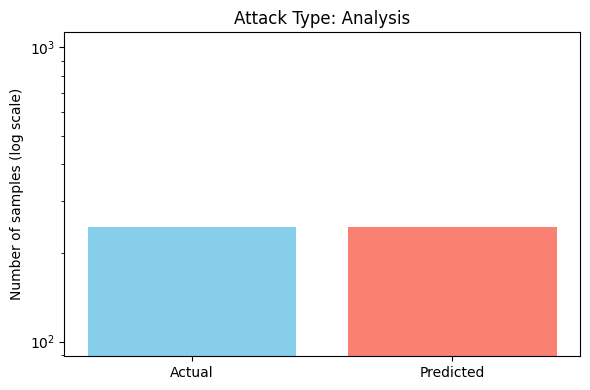

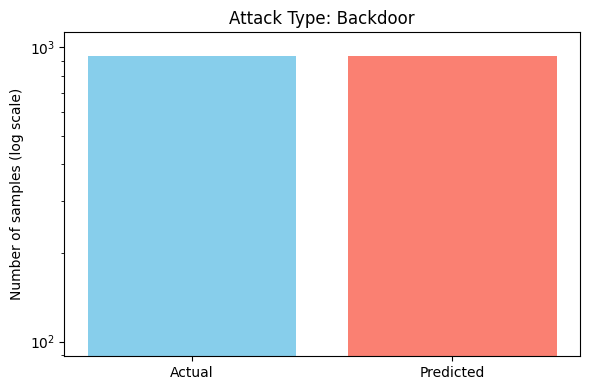

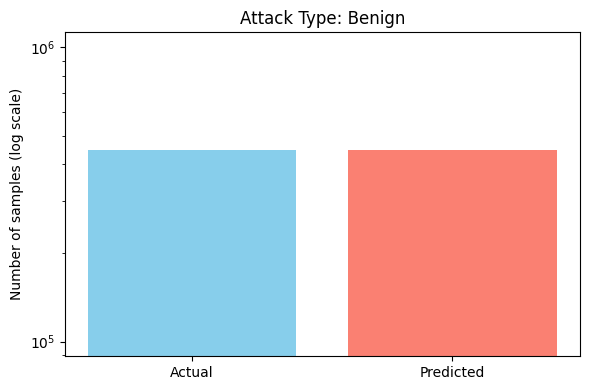

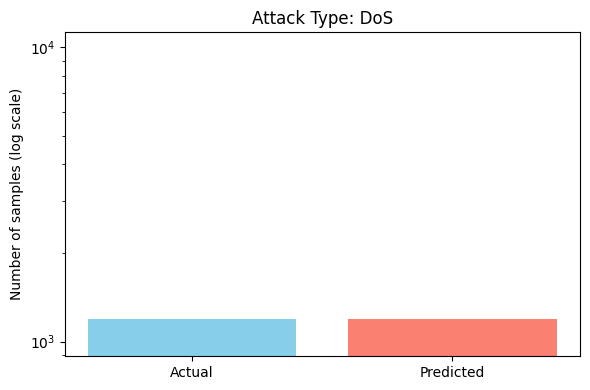

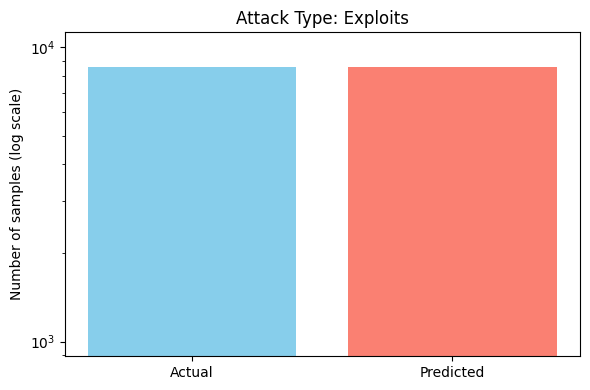

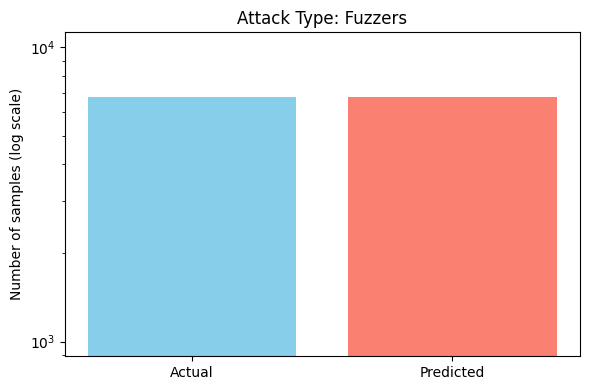

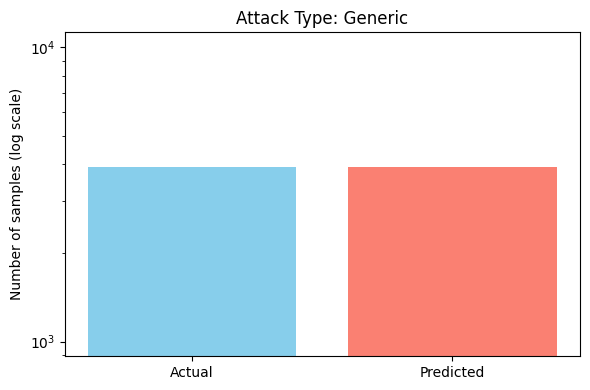

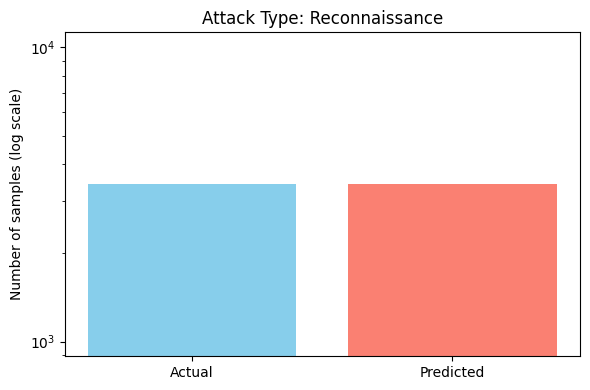

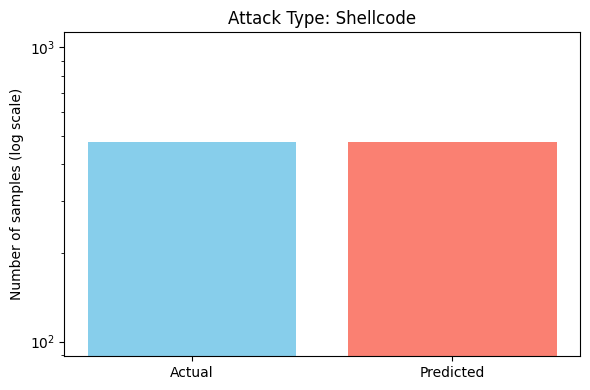

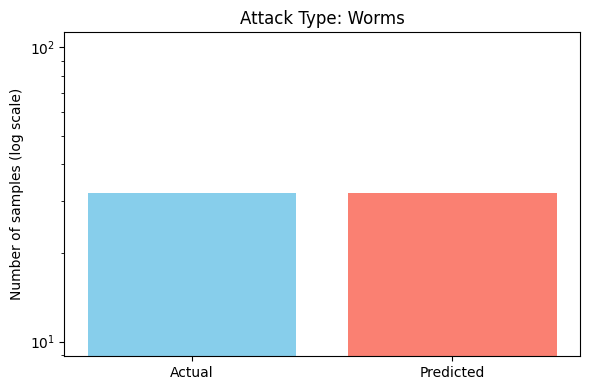

In [ ]:
for attack in classes:
    pred_count = np.sum(y_pred == attack)
    actual_count = np.sum(y_test == attack)
    
    plt.figure(figsize=(6,4))
    plt.bar(['Actual', 'Predicted'], [actual_count, pred_count], color=['skyblue','salmon'])
    
    plt.yscale('log')
    plt.ylabel('Number of samples (log scale)')
    plt.title(f'Attack Type: {attack}')
    plt.tight_layout()
    plt.show()